In [154]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Import Libraries**

In [155]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import csv

import re
import nltk
nltk.download('punkt')
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils import class_weight

!pip install wordcloud
from wordcloud import WordCloud

!pip install -q gensim
from gensim.models import Word2Vec

import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional, Concatenate
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


The above code attempts to identify lines where the number of columns does not match the expected 6 columns (based on your `df.head()` output). If the issue is with quotes or other `csv` formatting, the `csv.reader` might raise `csv.Error` which is also caught and reported. Review the output to see if specific lines are highlighted.

# **Exploratory Data Analysis (EDA)**

In [156]:
## Unmached row/column check

problematic_lines = []
with open(out_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
        try:
            if len(row) != 6:
                problematic_lines.append((i + 1, row))
        except csv.Error as e:
            problematic_lines.append((i + 1, row, str(e)))

if problematic_lines:
    print(f"Found {len(problematic_lines)} problematic lines:")
    for line_num, row_content in problematic_lines:
        print(f"Line {line_num}: {row_content}")
else:
    print("No problematic lines found with basic column count check.")

Found 4 problematic lines:
Line 76651: ['76649', '152297', '152298', "What's the difference between ", ' Æ and ©?"', 'What\'s the difference between "did" and "have done"?', '0']
Line 147357: ['147355', '291557', '291558', 'What is the relation between love, touch, kiss and sex?', ' What is the relation between love', ' touch', ' kiss and sex?"', '1']
Line 272874: ['272872', '536624', '536625', "What's the difference between ", ' Æ and ©?"', 'What is the difference between "of" and "for"?', '0']
Line 360136: ['360134', '705167', '484856', "What's the difference between ", ' Æ and ©?"', "What's the difference between it's and its?", '0']


In [157]:
df = pd.read_csv(out_path, encoding='utf-8', engine='python', on_bad_lines='skip')
df

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404314,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404315,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1
404316,404348,789796,789797,What is one coin?,What's this coin?,0
404317,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [158]:
df.head(10)

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
5,5,11,12,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan...",1
6,6,13,14,Should I buy tiago?,What keeps childern active and far from phone ...,0
7,7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1
8,8,17,18,When do you use ∑ instead of W?,"When do you use ""&"" instead of ""and""?",0
9,9,19,20,Motorola (company): Can I hack my Charter Moto...,How do I hack Motorola DCX3400 for free internet?,0


In [159]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404319 entries, 0 to 404318
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404319 non-null  int64 
 1   qid1          404319 non-null  int64 
 2   qid2          404319 non-null  int64 
 3   question1     404318 non-null  object
 4   question2     404317 non-null  object
 5   is_duplicate  404319 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [160]:
print ('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(df.shape,df.shape[0],df.shape[1]))

Shape of the dataset is (404319, 6). This dataset contains 404319 rows and 6 columns.


In [161]:
##Selecting numerical features
numerical_data = df.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:', '\n')
print(numerical_features)

There are 4 numerical features: 

['id', 'qid1', 'qid2', 'is_duplicate']


In [162]:
#Selecting categoricalfeatures
categorical_data=df.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:', '\n')
print(categorical_features)

There are 2 categorical features: 

['question1', 'question2']


In [163]:
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [164]:
numerical_data.nunique()

,0
id,404319
qid1,399303
qid2,397910
is_duplicate,2


In [165]:
categorical_data.nunique()

,0
question1,290449
question2,299177


In [166]:
df['question1'] = df['question1'].fillna("")
df['question2'] = df['question2'].fillna("")

In [167]:
print("Dataset shape:", df.shape)
print("\nColumn Info:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (404319, 6)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404319 entries, 0 to 404318
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404319 non-null  int64 
 1   qid1          404319 non-null  int64 
 2   qid2          404319 non-null  int64 
 3   question1     404319 non-null  object
 4   question2     404319 non-null  object
 5   is_duplicate  404319 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB
None

Missing values:
id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64


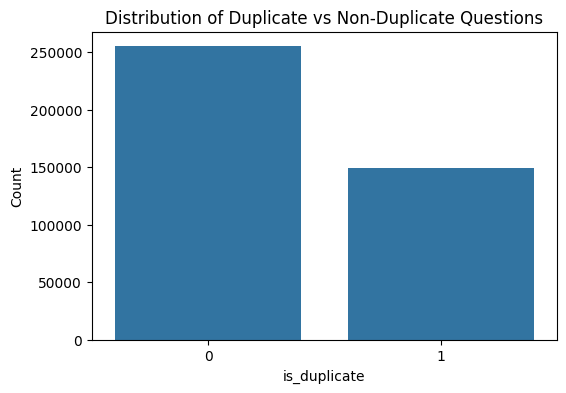

In [168]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["is_duplicate"])
plt.title("Distribution of Duplicate vs Non-Duplicate Questions")
plt.xlabel("is_duplicate")
plt.ylabel("Count")
plt.show()


In [169]:
duplicate_counts = df['is_duplicate'].value_counts()
total_questions = len(df)

percentage_non_duplicate = (duplicate_counts[0] / total_questions) * 100
percentage_duplicate = (duplicate_counts[1] / total_questions) * 100

print(f"Percentage of Non-Duplicate Questions (0): {percentage_non_duplicate:.2f}%")
print(f"Percentage of Duplicate Questions (1): {percentage_duplicate:.2f}%")

Percentage of Non-Duplicate Questions (0): 63.07%
Percentage of Duplicate Questions (1): 36.93%


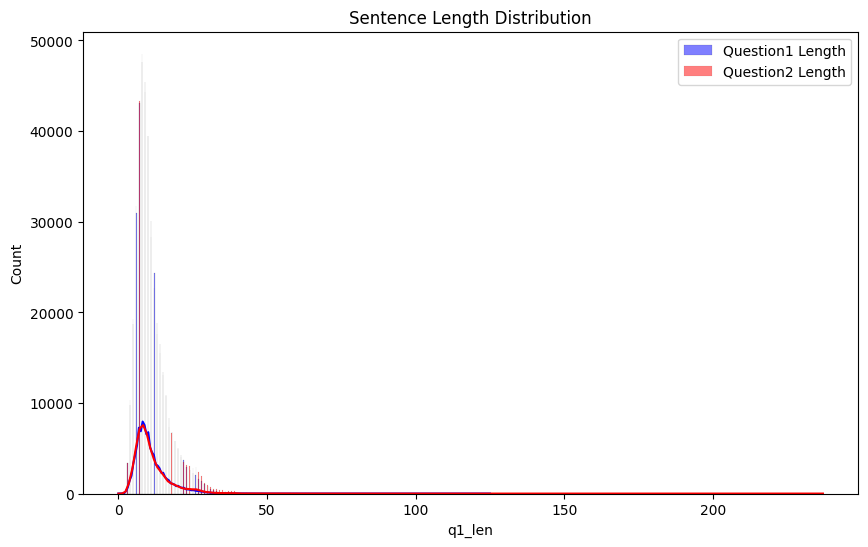

In [170]:
df['q1_len'] = df['question1'].astype(str).apply(lambda x: len(x.split()))
df['q2_len'] = df['question2'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))
sns.histplot(df['q1_len'], color="blue", label="Question1 Length", kde=True)
sns.histplot(df['q2_len'], color="red", label="Question2 Length", kde=True)
plt.legend()
plt.title("Sentence Length Distribution")
plt.show()


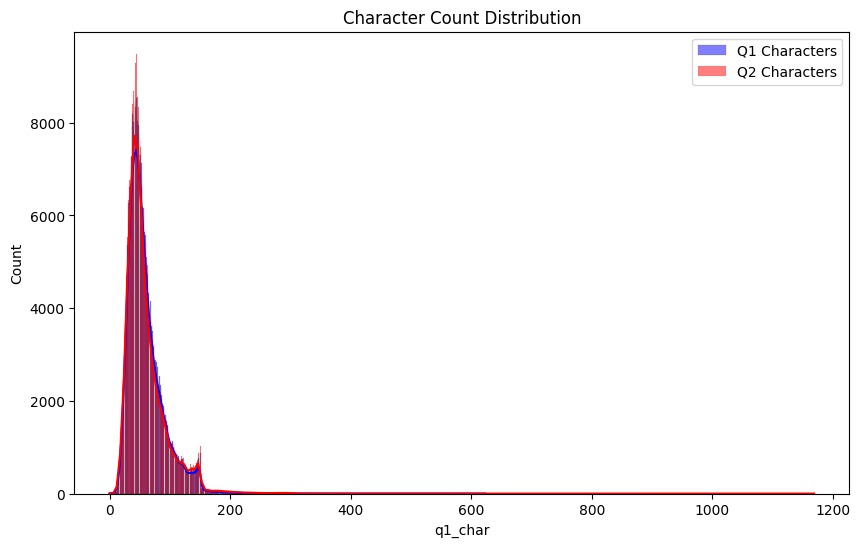

In [171]:
df['q1_char'] = df['question1'].astype(str).apply(len)
df['q2_char'] = df['question2'].astype(str).apply(len)

plt.figure(figsize=(10,6))
sns.histplot(df['q1_char'], color="blue", label="Q1 Characters", kde=True)
sns.histplot(df['q2_char'], color="red", label="Q2 Characters", kde=True)
plt.legend()
plt.title("Character Count Distribution")
plt.show()


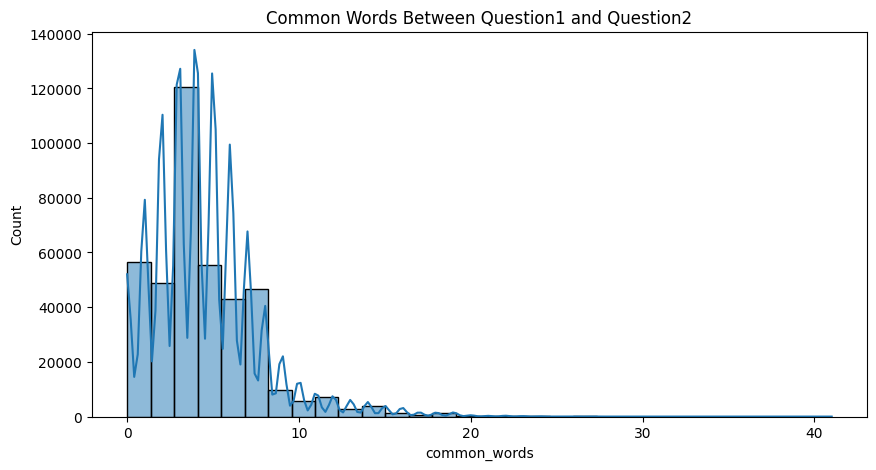

In [172]:
def common_words(q1, q2):
    w1 = set(str(q1).lower().split())
    w2 = set(str(q2).lower().split())
    return len(w1.intersection(w2))

df["common_words"] = df.apply(lambda x: common_words(x["question1"], x["question2"]), axis=1)

plt.figure(figsize=(10,5))
sns.histplot(df["common_words"], bins=30, kde=True)
plt.title("Common Words Between Question1 and Question2")
plt.show()


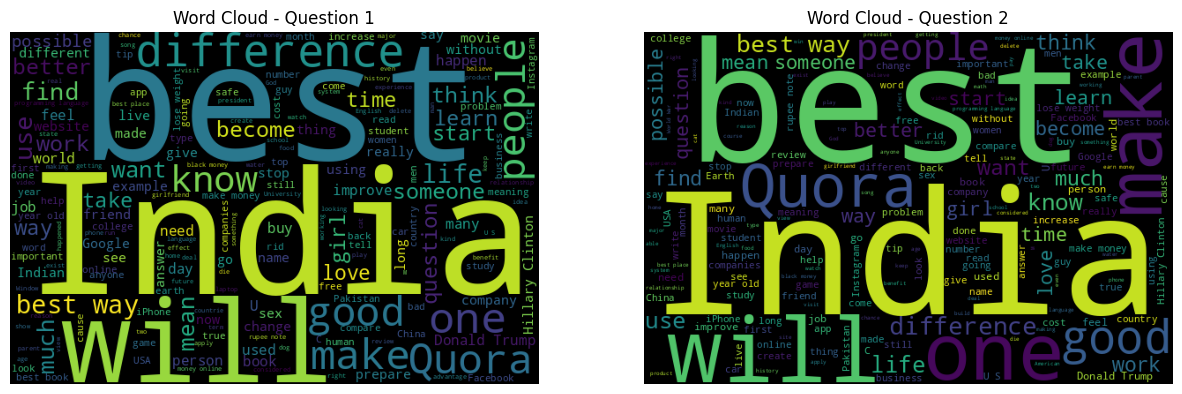

In [173]:
# Combine all text
q1_text = " ".join(df['question1'].astype(str).tolist())
q2_text = " ".join(df['question2'].astype(str).tolist())

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.title("Word Cloud - Question 1")
plt.imshow(WordCloud(width=600, height=400).generate(q1_text))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Word Cloud - Question 2")
plt.imshow(WordCloud(width=600, height=400).generate(q2_text))
plt.axis("off")

plt.show()


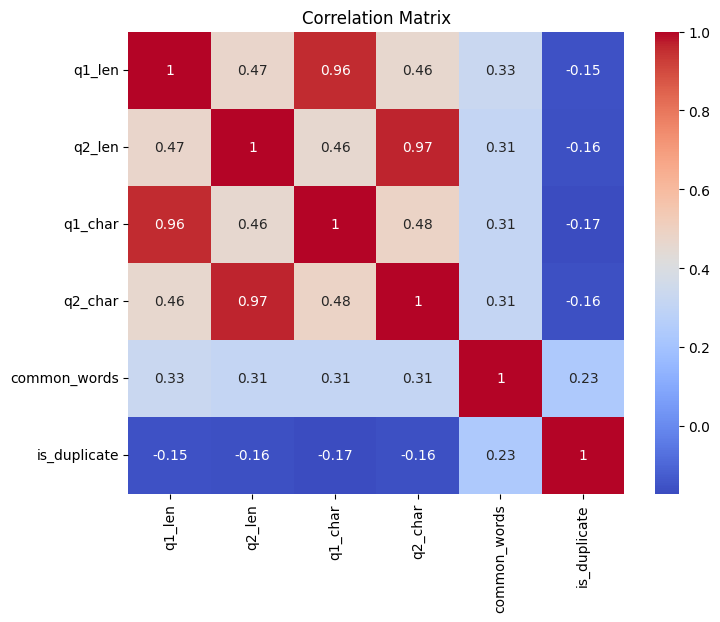

In [174]:
corr = df[['q1_len','q2_len','q1_char','q2_char','common_words','is_duplicate']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


# **Text Preprocessing**

In [175]:
# Drop rows where question1 or question2 is missing
df = df.dropna(subset=['question1', 'question2']).reset_index(drop=True)

print("New dataframe shape:", df.shape)
print(df.isnull().sum())


New dataframe shape: (404319, 11)
id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
q1_len          0
q2_len          0
q1_char         0
q2_char         0
common_words    0
dtype: int64


In [176]:
# Tokenization
# Creates token lists for q1 and q2 (raw split on whitespace)
df['q1_tokens_raw'] = df['question1'].astype(str).apply(lambda s: s.split())
df['q2_tokens_raw'] = df['question2'].astype(str).apply(lambda s: s.split())

print("Example tokens Q1:", df['q1_tokens_raw'].iat[0])
print("Example tokens Q2:", df['q2_tokens_raw'].iat[0])


Example tokens Q1: ['What', 'is', 'the', 'step', 'by', 'step', 'guide', 'to', 'invest', 'in', 'share', 'market', 'in', 'india?']
Example tokens Q2: ['What', 'is', 'the', 'step', 'by', 'step', 'guide', 'to', 'invest', 'in', 'share', 'market?']


In [177]:
# Lowercasing
df['q1_lower'] = df['question1'].astype(str).str.lower()
df['q2_lower'] = df['question2'].astype(str).str.lower()

print(df[['q1_lower','q2_lower']].head(2).to_string(index=False))

                                                          q1_lower                                                                                 q2_lower
what is the step by step guide to invest in share market in india?                                what is the step by step guide to invest in share market?
               what is the story of kohinoor (koh-i-noor) diamond? what would happen if the indian government stole the kohinoor (koh-i-noor) diamond back?


In [178]:
# Remove special characters & punctuation (keep only a-z and spaces)
import re

def remove_special(text):
    text = re.sub(r'[^a-z\s]', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['q1_alpha'] = df['q1_lower'].apply(remove_special)
df['q2_alpha'] = df['q2_lower'].apply(remove_special)

print(df[['q1_alpha','q2_alpha']].head(2).to_string(index=False))

                                                         q1_alpha                                                                              q2_alpha
what is the step by step guide to invest in share market in india                              what is the step by step guide to invest in share market
                 what is the story of kohinoor koh i noor diamond what would happen if the indian government stole the kohinoor koh i noor diamond back


In [179]:
# Stopword removal + tokenization of cleaned text
def remove_stop_and_tokenize(text):
    tokens = [w for w in str(text).split() if w not in STOPWORDS]
    return tokens

df['q1_tokens_clean'] = df['q1_alpha'].apply(remove_stop_and_tokenize)
df['q2_tokens_clean'] = df['q2_alpha'].apply(remove_stop_and_tokenize)

df['q1_clean_str'] = df['q1_tokens_clean'].apply(lambda toks: " ".join(toks))
df['q2_clean_str'] = df['q2_tokens_clean'].apply(lambda toks: " ".join(toks))

print("Clean tokens Q1 example:", df['q1_tokens_clean'].iat[0])
print("Clean string Q1 example:", df['q1_clean_str'].iat[0])


Clean tokens Q1 example: ['step', 'step', 'guide', 'invest', 'share', 'market', 'india']
Clean string Q1 example: step step guide invest share market india


In [180]:
# Lemmatization of cleaned tokens
def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

df['q1_lem_tokens'] = df['q1_tokens_clean'].apply(lemmatize_tokens)
df['q2_lem_tokens'] = df['q2_tokens_clean'].apply(lemmatize_tokens)

df['q1_final'] = df['q1_lem_tokens'].apply(lambda toks: " ".join(toks))
df['q2_final'] = df['q2_lem_tokens'].apply(lambda toks: " ".join(toks))

print(df[['q1_final','q2_final']].head(2).to_string(index=False))


                                 q1_final                                                            q2_final
step step guide invest share market india                                 step step guide invest share market
          story kohinoor koh noor diamond would happen indian government stole kohinoor koh noor diamond back


In [181]:
# tune max_features/ngram_range
tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1,2))

combined_corpus = pd.concat([df['q1_final'], df['q2_final']])
tfidf.fit(combined_corpus)

q1_tfidf = tfidf.transform(df['q1_final'])
q2_tfidf = tfidf.transform(df['q2_final'])

print("TF-IDF fitted. q1 shape:", q1_tfidf.shape, " q2 shape:", q2_tfidf.shape)


TF-IDF fitted. q1 shape: (404319, 30000)  q2 shape: (404319, 30000)


In [182]:
# Word2Vec embeddings (average of token vectors)
sentences = df['q1_lem_tokens'].tolist() + df['q2_lem_tokens'].tolist()

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, epochs=5)


def avg_w2v(tokens, model, vector_size=100):
    vecs = []
    for t in tokens:
        if t in model.wv:
            vecs.append(model.wv[t])
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

q1_w2v = np.vstack(df['q1_lem_tokens'].apply(lambda toks: avg_w2v(toks, w2v_model)).values)
q2_w2v = np.vstack(df['q2_lem_tokens'].apply(lambda toks: avg_w2v(toks, w2v_model)).values)

print("Word2Vec sentence vectors shapes: q1:", q1_w2v.shape, " q2:", q2_w2v.shape)


Word2Vec sentence vectors shapes: q1: (404319, 100)  q2: (404319, 100)


In [183]:
print("Empty q1_final:", (df['q1_final'].str.strip() == "").sum())
print("Empty q2_final:", (df['q2_final'].str.strip() == "").sum())

# show a few problematic rows if any
display(df[df['q1_final'].str.strip() == ""].head(3))
display(df[df['q2_final'].str.strip() == ""].head(3))


Empty q1_final: 175
Empty q2_final: 170


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_char,q2_char,...,q1_alpha,q2_alpha,q1_tokens_clean,q2_tokens_clean,q1_clean_str,q2_clean_str,q1_lem_tokens,q2_lem_tokens,q1_final,q2_final
918,918,1837,1838,I'm 18. What should I do?,What can I do when I'm 18?,1,6,7,25,26,...,i m what should i do,what can i do when i m,[],[],,,[],[],,
1510,1510,3021,3022,"If 204=8, 503=13, 305=11 and 907=25, what is 705?",Why can I not multiply fractions in Python?,0,9,8,49,43,...,if and what is,why can i not multiply fractions in python,[],"[multiply, fractions, python]",,multiply fractions python,[],"[multiply, fraction, python]",,multiply fraction python
3305,3305,6608,6609,.,Why is Cornell's endowment the lowest in the I...,0,1,10,1,56,...,,why is cornell s endowment the lowest in the i...,[],"[cornell, endowment, lowest, ivy, league]",,cornell endowment lowest ivy league,[],"[cornell, endowment, lowest, ivy, league]",,cornell endowment lowest ivy league


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_char,q2_char,...,q1_alpha,q2_alpha,q1_tokens_clean,q2_tokens_clean,q1_clean_str,q2_clean_str,q1_lem_tokens,q2_lem_tokens,q1_final,q2_final
918,918,1837,1838,I'm 18. What should I do?,What can I do when I'm 18?,1,6,7,25,26,...,i m what should i do,what can i do when i m,[],[],,,[],[],,
7120,7120,14222,14223,Is it proper to use a comma after saying thank...,What is here and not there?,0,11,6,51,27,...,is it proper to use a comma after saying thank...,what is here and not there,"[proper, use, comma, saying, thank]",[],proper use comma saying thank,,"[proper, use, comma, saying, thank]",[],proper use comma saying thank,
7368,7368,14718,14719,What is 9 + 10 + 2?,What is 9 + 10?,0,7,5,19,15,...,what is,what is,[],[],,,[],[],,


# **Model Build and Training**

In [184]:
# Logistic Regression (Baseline)
X_diff = (q1_tfidf - q2_tfidf).copy()
X_diff.data = np.abs(X_diff.data)
X_mul = q1_tfidf.multiply(q2_tfidf)
X = hstack([X_diff, X_mul])
y = df['is_duplicate'].values

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle imbalance with class_weight
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='sag', n_jobs=-1, class_weight='balanced')
lr_model.fit(X_train_lr, y_train_lr)

LogisticRegression(class_weight='balanced', max_iter=1000, n_jobs=-1,
                   solver='sag')

In [189]:
# Siamese Shared LSTM

MAX_VOCAB = 50000
MAX_LEN = 40
EMBED_DIM = 100
LSTM_UNITS = 64
BATCH_SIZE = 512
EPOCHS = 5

tokenizer = Tokenizer(num_words=MAX_VOCAB)
tokenizer.fit_on_texts(pd.concat([df['q1_final'], df['q2_final']]))

q1_seq = tokenizer.texts_to_sequences(df['q1_final'])
q2_seq = tokenizer.texts_to_sequences(df['q2_final'])
q1_pad = pad_sequences(q1_seq, maxlen=MAX_LEN, padding='post', truncating='post')
q2_pad = pad_sequences(q2_seq, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    np.stack([q1_pad, q2_pad], axis=1), y, test_size=0.2, random_state=42, stratify=y
)

q1_train = X_train_lstm[:,0,:]; q2_train = X_train_lstm[:,1,:]
q1_test = X_test_lstm[:,0,:]; q2_test = X_test_lstm[:,1,:]

# Compute class weights for LSTM
class_weights_values = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_lstm),
    y=y_train_lstm
)
class_weights_dict = dict(enumerate(class_weights_values))

# Shared encoder
def build_encoder(vocab_size, embed_dim=EMBED_DIM, lstm_units=LSTM_UNITS, max_len=MAX_LEN):
    inp = Input(shape=(max_len,))
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=max_len)(inp)
    x = Bidirectional(LSTM(lstm_units, return_sequences=False))(x)
    return Model(inp, x)

encoder = build_encoder(vocab_size=min(MAX_VOCAB, len(tokenizer.word_index)+1))

# Inputs
q1_in = Input(shape=(MAX_LEN,))
q2_in = Input(shape=(MAX_LEN,))
q1_vec = encoder(q1_in)
q2_vec = encoder(q2_in)

abs_diff = Lambda(lambda tensors: tf.math.abs(tensors[0] - tensors[1]))([q1_vec, q2_vec])
mult = Lambda(lambda tensors: tensors[0] * tensors[1])([q1_vec, q2_vec])
merged = Concatenate()([q1_vec, q2_vec, abs_diff, mult])

x = Dense(256, activation='relu')(merged)
x = Dropout(0.25)(x)
x = Dense(64, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

lstm_model = Model(inputs=[q1_in, q2_in], outputs=out)
lstm_model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Pass class_weights to handle imbalance
history = lstm_model.fit(
    [q1_train, q2_train], y_train_lstm,
    validation_data=([q1_test, q2_test], y_test_lstm),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[es],
    class_weight=class_weights_dict,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
632/632 ━━━━━━━━━━━━━━━━━━━━ 642s 1s/step - accuracy: 0.7185 - loss: 0.5306 - val_accuracy: 0.8018 - val_loss: 0.4213
Epoch 2/5
632/632 ━━━━━━━━━━━━━━━━━━━━ 591s 933ms/step - accuracy: 0.8444 - loss: 0.3393 - val_accuracy: 0.8107 - val_loss: 0.4088
Epoch 3/5
632/632 ━━━━━━━━━━━━━━━━━━━━ 631s 998ms/step - accuracy: 0.8829 - loss: 0.2601 - val_accuracy: 0.8157 - val_loss: 0.4200
Epoch 4/5
632/632 ━━━━━━━━━━━━━━━━━━━━ 633s 1s/step - accuracy: 0.9063 - loss: 0.2104 - val_accuracy: 0.8113 - val_loss: 0.4712


# **Model Evaluation**

=== Logistic Regression Evaluation ===
Accuracy: 0.7943213296398892
Precision: 0.6824954472711219
Recall: 0.8283657066309444
F1 Score: 0.7483888535899065
ROC AUC: 0.8848300332275004


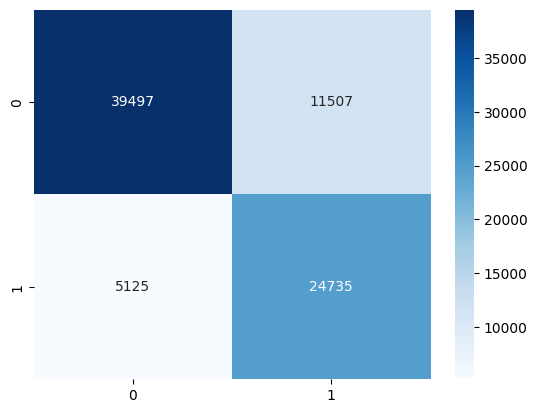

In [186]:
# Logistic Regression Evaluation
y_pred_lr = lr_model.predict(X_test_lr)
y_proba_lr = lr_model.predict_proba(X_test_lr)[:,1]

print("=== Logistic Regression Evaluation ===")
print("Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print("Precision:", precision_score(y_test_lr, y_pred_lr))
print("Recall:", recall_score(y_test_lr, y_pred_lr))
print("F1 Score:", f1_score(y_test_lr, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test_lr, y_proba_lr))
cm_lr = confusion_matrix(y_test_lr, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues'); plt.show()

79/79 ━━━━━━━━━━━━━━━━━━━━ 46s 561ms/step
=== Siamese LSTM Evaluation ===
Accuracy: 0.8080233478432924
Precision: 0.693416082029142
Recall: 0.8606162089752177
F1 Score: 0.7680215182307233
ROC AUC: 0.8971162168151134


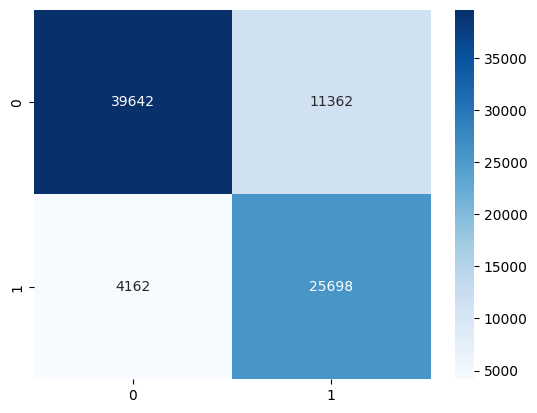

In [187]:
# Siamese LSTM Evaluation
y_proba_lstm = lstm_model.predict([q1_test, q2_test], batch_size=1024).ravel()
y_pred_lstm = (y_proba_lstm > 0.5).astype(int)

print("=== Siamese LSTM Evaluation ===")
print("Accuracy:", accuracy_score(y_test_lstm, y_pred_lstm))
print("Precision:", precision_score(y_test_lstm, y_pred_lstm))
print("Recall:", recall_score(y_test_lstm, y_pred_lstm))
print("F1 Score:", f1_score(y_test_lstm, y_pred_lstm))
print("ROC AUC:", roc_auc_score(y_test_lstm, y_proba_lstm))
cm_lstm = confusion_matrix(y_test_lstm, y_pred_lstm)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues'); plt.show()

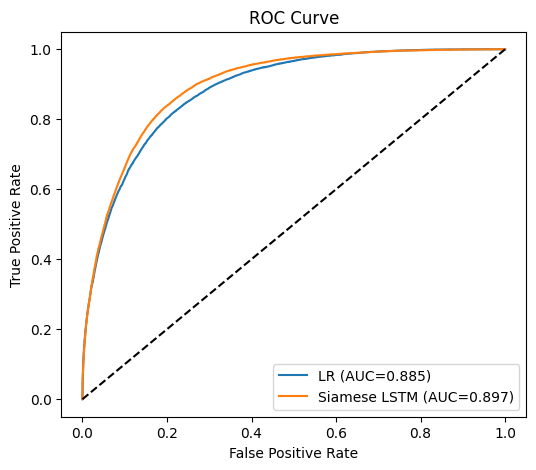

In [188]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, y_proba_lstm)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f'LR (AUC={auc(fpr_lr, tpr_lr):.3f})')
plt.plot(fpr_lstm, tpr_lstm, label=f'Siamese LSTM (AUC={auc(fpr_lstm, tpr_lstm):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()